In [29]:
#Level 1: Basic Data Review
# Task 1.1: Overview of dataset – total records & attributes 

import pandas as pd
df = pd.read_csv("Dataset1.csv")
df.shape

(186074, 12)

In [30]:
#Task 1.2: List all trains with their starting and ending stations

import pandas as pd
df = pd.read_csv("Dataset1.csv")

df = df.sort_values(["Train_No", "SN"])
grouped = df.groupby("Train_No")  

train_routes = pd.DataFrame({
    "Start_Station": grouped["Station_Name"].first(),
    "End_Station": grouped["Station_Name"].last()
})

train_routes = train_routes.reset_index()

train_routes.head()

,Train_No,Start_Station,End_Station
0,107,SAWANTWADI R,MADGOAN JN.
1,108,MADGOAN JN.,SAWANTWADI R
2,128,MADGOAN JN.,CHHATRAPATI
3,290,DELHI-SAFDAR,DELHI-SAFDAR
4,401,AURANGABAD,VARANASI JN.


In [31]:
#Task 1.3: Calculate the number of stops per train

stop_count = grouped.size().reset_index(name="Stops")
stop_count.head()

,Train_No,Stops
0,107,4
1,108,4
2,128,22
3,290,14
4,401,12


In [32]:
#Task 1.4: Identify trains with maximum and minimum stops

max_train = stop_count.loc[stop_count["Stops"].idxmax()]
print(max_train)

min_train = stop_count.loc[stop_count["Stops"].idxmin()]
print(min_train)

stop_count["Stops"].idxmax()
stop_count.loc[...]

Train_No    53041
Stops         118
Name: 5977, dtype: int64
Train_No    557
Stops         2
Name: 11, dtype: int64


,Train_No,Stops
0,107,4
1,108,4
2,128,22
3,290,14
4,401,12
...,...,...
11108,99904,12
11109,99905,11
11110,99906,12
11111,99907,12


In [33]:
#Level 2: Simple Data Processing
#2.1: Standardize schedule fields (arrival & departure times)

df["Arrival_time"] = pd.to_datetime(
    df["Arrival_time"],
    format="%H:%M:%S",
    errors="coerce"
)


df["Departure_Time"] = pd.to_datetime(
    df["Departure_Time"],
    format="%H:%M:%S",
    errors="coerce"
)


df = df.sort_values(["Train_No", "SN"])
grouped = df.groupby("Train_No")

df[["Arrival_time", "Departure_Time"]].dtypes

Arrival_time      datetime64[us]
Departure_Time    datetime64[us]
dtype: object

In [34]:
#2.2: Compute total journey duration for each train

# Get Train 107
train107 = df[df["Train_No"] == 107]

# Starting departure
start = train107["Departure_Time"].iloc[0]

# Final arrival
end = train107["Arrival_time"].iloc[-1]

# Handle midnight
if end <= start:
    end = end + pd.Timedelta(days=1)

# Calculate duration
duration = end - start

#journey_duration = grouped.apply(calculate_duration)
#journey_duration = journey_duration.reset_index(name="Journey_Duration")
#journey_duration[journey_duration["Train_No"] == 107] duration

In [35]:
# For Each Train

def calculate_duration(train):
    start = train["Departure_Time"].iloc[0]
    end = train["Arrival_time"].iloc[-1]

    if end <= start:
        end = end + pd.Timedelta(days=1)

    return end - start

journey_duration = grouped.apply(calculate_duration)
journey_duration.head()


journey_duration = journey_duration.reset_index(name="Journey_Duration")

journey_duration.head()

train_routes = train_routes.merge(
    journey_duration,
    on="Train_No",
    how="left"
)

train_routes.head()

,Train_No,Start_Station,End_Station,Journey_Duration
0,107,SAWANTWADI R,MADGOAN JN.,0 days 01:45:00
1,108,MADGOAN JN.,SAWANTWADI R,0 days 01:55:00
2,128,MADGOAN JN.,CHHATRAPATI,0 days 22:05:00
3,290,DELHI-SAFDAR,DELHI-SAFDAR,0 days 08:00:00
4,401,AURANGABAD,VARANASI JN.,0 days 12:30:00


In [36]:
# Task 2.3: Classify routes as short, medium, or long
# Short   → ≤ 3 hours
# Medium  → >3 and ≤8 hours
# Long    → >8 hours

train_routes["Journey_Hours"] = (
    train_routes["Journey_Duration"].dt.total_seconds() / 3600
)
train_routes[["Train_No", "Journey_Duration", "Journey_Hours"]].head()

def classify_route(hours):
    if hours <= 3:
        return "Short"
    elif hours <= 8:
        return "Medium"
    else:
        return "Long" 


train_routes["Route_Type"] = train_routes["Journey_Hours"].apply(classify_route)
train_routes[["Train_No", "Journey_Hours", "Route_Type"]].head(10)
train_routes["Route_Type"] = train_routes["Journey_Hours"].apply(classify_route)
train_routes["Route_Type"].value_counts()

Route_Type
Short     6620
Medium    2364
Long      2129
Name: count, dtype: int64

In [37]:
# Task 2.4: Generate station-wise train frequency counts

df.groupby("Station_Name")["Train_No"].nunique()

station_frequency = (
    df.groupby("Station_Name")["Train_No"]
      .nunique()
      .reset_index(name="Train_Frequency")
)

station_frequency = station_frequency.sort_values(
    "Train_Frequency",
    ascending=False
)
station_frequency.iloc[0]
station_frequency.head(10)

,Station_Name,Train_Frequency
1755,CST-MUMBAI,1027
3466,KALYAN JN,828
7509,THANE,796
6834,SEALDAH,745
1592,CHENNAI BEAC,738
2950,HOWRAH JN.,699
1773,DADAR,598
2213,DUM DUM JN.,463
4245,KURLA,462
7401,TAMBARAM,434


In [38]:
# Level 3: Data Quality Checks
# Task 3.1: Handle missing schedule values

df.isnull().sum()

SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64

In [39]:
# Task 3.2: Remove duplicate train records

df.duplicated().sum()

np.int64(0)

In [40]:
# Task 3.3: Verify correct station order in each route

sn_issues = (
    df.groupby("Train_No")["SN"]
      .diff()
      .dropna()
      .le(0)
      .sum()
)

sn_issues

np.int64(0)

In [41]:
# Task 3.4: Save the verified dataset

df.to_csv("cleaned_train_schedule.csv", index=False)

print("Verified dataset saved successfully.")



Verified dataset saved successfully.


In [42]:
# Level 4: Basic Analysis and Visualization
# Task 4.1: Compare average journey durations across route types

avg_duration = (
    train_routes.groupby("Route_Type")["Journey_Hours"]
    .mean()
    .reset_index()
)

avg_duration

,Route_Type,Journey_Hours
0,Long,14.293354
1,Medium,5.063304
2,Short,1.339290


In [43]:
# Task 4.2: Identify high-traffic stations

top_stations = station_frequency.head(10)

top_stations

,Station_Name,Train_Frequency
1755,CST-MUMBAI,1027
3466,KALYAN JN,828
7509,THANE,796
6834,SEALDAH,745
1592,CHENNAI BEAC,738
2950,HOWRAH JN.,699
1773,DADAR,598
2213,DUM DUM JN.,463
4245,KURLA,462
7401,TAMBARAM,434


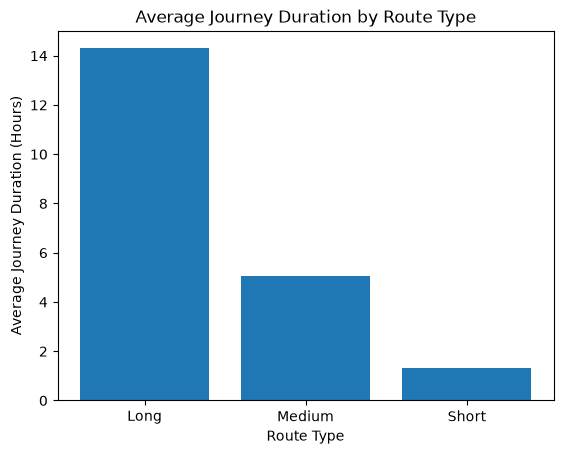

In [44]:
# Task 4.3: Create basic visualizations for journey duration and station traffic

import matplotlib.pyplot as plt
plt.bar(avg_duration["Route_Type"], avg_duration["Journey_Hours"])

plt.xlabel("Route Type")
plt.ylabel("Average Journey Duration (Hours)")
plt.title("Average Journey Duration by Route Type")

plt.show()

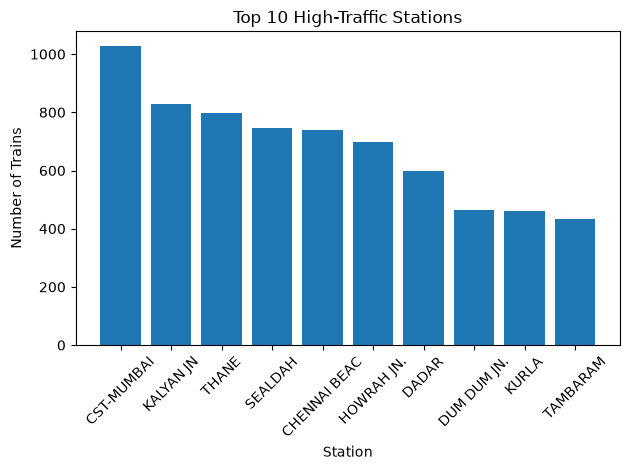

In [45]:
# Task 4.4: Summarize key observations

plt.bar(top_stations["Station_Name"], top_stations["Train_Frequency"])

plt.xlabel("Station")
plt.ylabel("Number of Trains")
plt.title("Top 10 High-Traffic Stations")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [46]:
''' 
Observation: A higher number of trains serving a station indicates
greater connectivity to different routes and destinations. 
This can increase the station's overall passenger movement
and make it an important transportation hub
   '''

" \nObservation: A higher number of trains serving a station indicates\ngreater connectivity to different routes and destinations. \nThis can increase the station's overall passenger movement\nand make it an important transportation hub\n   "

In [47]:
df = df.merge(
    train_routes[["Train_No", "Route_Type"]],
    on="Train_No",
    how="left"
)

In [48]:
df[["Train_No", "Station_Name", "Route_Type"]].head()

,Train_No,Station_Name,Route_Type
0,107,SAWANTWADI R,Short
1,107,THIVIM,Short
2,107,KARMALI,Short
3,107,MADGOAN JN.,Short
4,108,MADGOAN JN.,Short


In [49]:
# Level 5: Advanced Analysis and Visualization

pivot = pd.pivot_table(
    df,
    index="Station_Name",
    columns="Route_Type",
    values="Train_No",
    aggfunc=pd.Series.nunique,
    fill_value=0
)

pivot.head(10)

Route_Type,Long,Medium,Short
Station_Name,,,
.BAGHAJATIN,0,1,216
ABADA,1,22,67
ABHAIPUR,31,18,13
ABHANPUR JN.,0,0,12
ABHAYAPURI A,2,4,0
ABJUGANJ,0,4,2
ABOHAR,16,11,1
ABU ROAD,66,19,15
ABUTARA HALT,2,2,2


In [50]:
# Task 5.2: Cross-tabulations to analyze train frequency between stations and routes

long_route_stations = (
    pivot.sort_values("Long", ascending=False)
    .head(10)
)

long_route_stations

Route_Type,Long,Medium,Short
Station_Name,,,
VADODARA JN.,257,75,44
LUCKNOW JN.,224,96,65
KANPUR CENTR,221,96,65
SURAT,218,67,31
VIJAYWADA JN,212,132,72
AHMEDABAD,206,53,46
ITARSI,197,63,31
BHUSAVAL JN.,195,76,27
MUGHAL SARAI,179,79,33


In [ ]:
# Task 5.3: Visualize pivot and cross-tab results with comparative chart

top_10_stations = pivot.loc[
    long_route_stations.index
]

top_10_stations

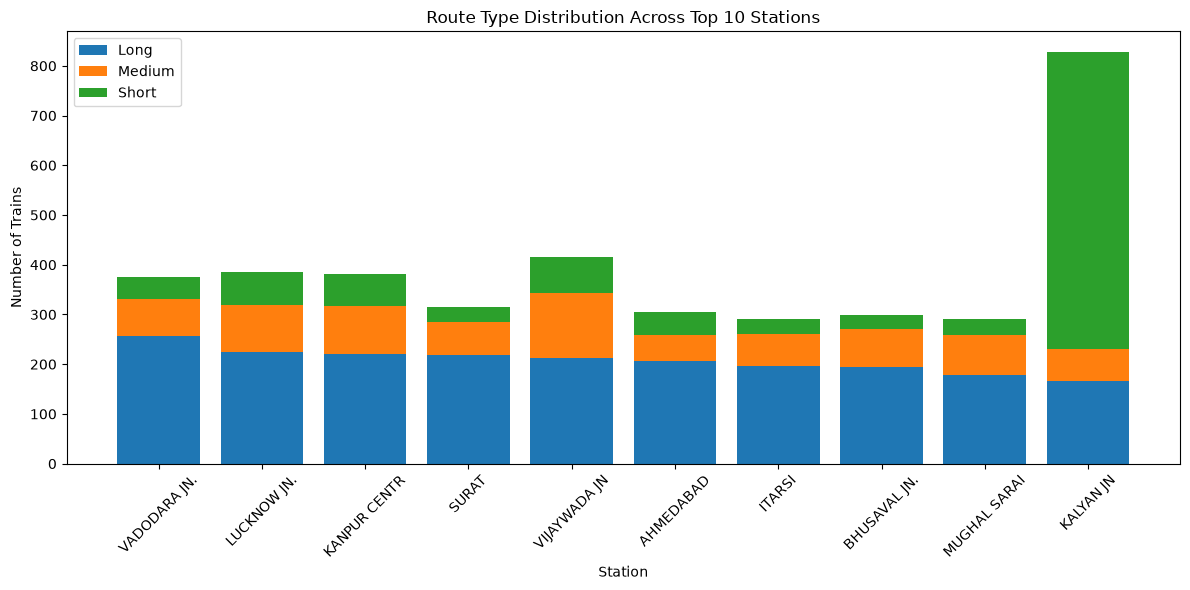

In [ ]:
#Comparative Route-Type Chart

plt.figure(figsize=(12, 6))

x = range(len(top_10_stations))

plt.bar(x, top_10_stations["Long"], label="Long")
plt.bar(x, top_10_stations["Medium"], bottom=top_10_stations["Long"], label="Medium")
plt.bar(
    x,
    top_10_stations["Short"],
    bottom=top_10_stations["Long"] + top_10_stations["Medium"],
    label="Short"
)

plt.xticks(x, top_10_stations.index, rotation=45)
plt.xlabel("Station")
plt.ylabel("Number of Trains")
plt.title("Route Type Distribution Across Top 10 Stations")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Crosstab

cross_tab = pd.crosstab(
    df["Station_Name"],
    df["Route_Type"]
)

cross_tab.head(10)

Route_Type,Long,Medium,Short
Station_Name,,,
.BAGHAJATIN,0,1,216
ABADA,1,22,67
ABHAIPUR,31,18,13
ABHANPUR JN.,0,0,12
ABHAYAPURI A,2,4,0
ABJUGANJ,0,4,2
ABOHAR,16,11,1
ABU ROAD,66,19,15
ABUTARA HALT,2,2,2


In [54]:
# Dominant Station for Each Route Type

for route_type in ["Long", "Medium", "Short"]:
    station = pivot[route_type].idxmax()
    count = pivot[route_type].max()
    
    print(route_type, ":", station, "-", count)

Long : VADODARA JN. - 257
Medium : HOWRAH JN. - 147
Short : CST-MUMBAI - 929
